Loaded images shape: (2767, 128, 128, 3)
Loaded labels shape: (2767,)
Flattened input shape: (2767, 49152)
Training samples: (2213, 49152)
Testing samples: (554, 49152)
Random Forest training complete.
OOB Score: 0.8766

Test Accuracy: 0.9025

Classification Report:
                  precision    recall  f1-score   support

   Hariana Front       0.85      0.94      0.89       175
    Hariana Left       0.96      0.84      0.89        61
Red_Sindhi Front       0.92      0.84      0.88        43
 Red_Sindhi Left       1.00      0.97      0.98        29
   Sahiwal Front       0.91      0.94      0.93        54
    Sahiwal Left       1.00      0.93      0.96        44
 Tharparkar Left       1.00      0.87      0.93        54
Tharparker Front       0.85      0.86      0.86        94

        accuracy                           0.90       554
       macro avg       0.94      0.90      0.92       554
    weighted avg       0.91      0.90      0.90       554


Confusion Matrix:
[[165   2   0  

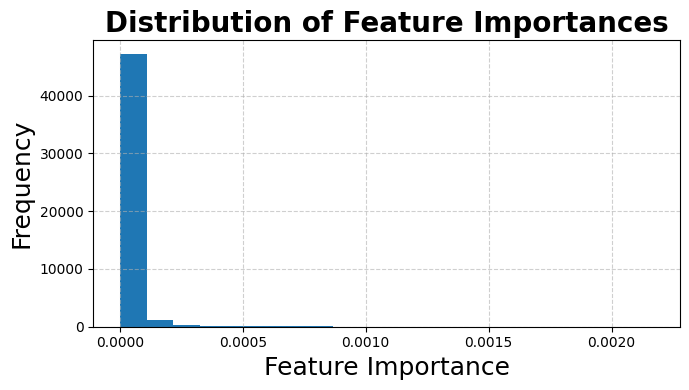

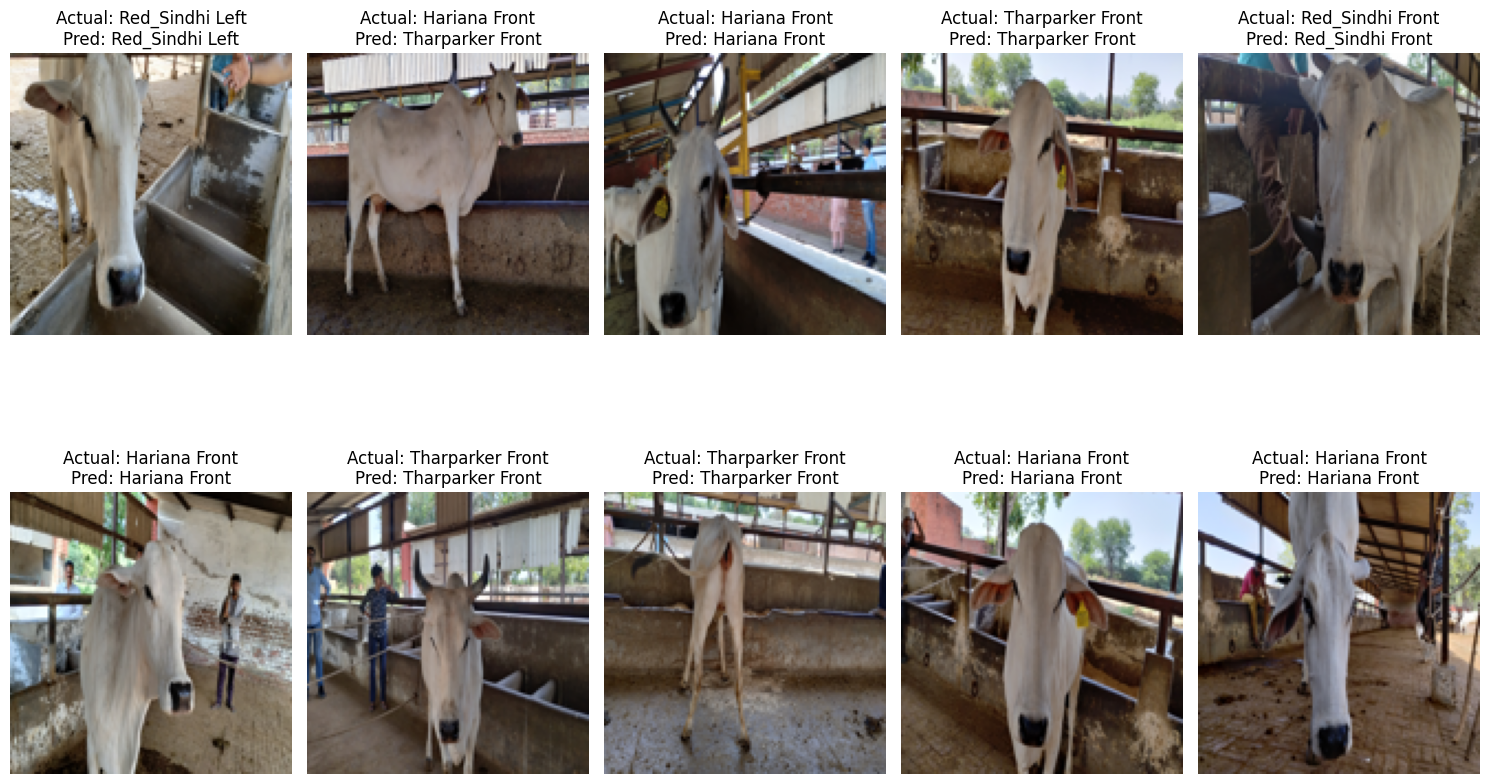

In [1]:
# -*- coding: utf-8 -*-
# Random Forest Image Classification Model

import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load Dataset
# =========================

image_dataset_path = '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/Dataset/'
output_filename = 'preprocessed_image_dataset.npz'
full_output_path = os.path.join(image_dataset_path, output_filename)

loaded_data = np.load(full_output_path)
loaded_images = loaded_data['images']
loaded_labels = loaded_data['labels']

print(f"Loaded images shape: {loaded_images.shape}")
print(f"Loaded labels shape: {loaded_labels.shape}")

# =========================
# Encode Labels
# =========================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(loaded_labels)

# =========================
# Flatten Images for RF
# =========================

X = loaded_images.reshape(loaded_images.shape[0], -1)
y = encoded_labels

print("Flattened input shape:", X.shape)

# =========================
# Train-Test Split
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape}")
print(f"Testing samples: {X_test.shape}")

# =========================
# Train Random Forest
# =========================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

# =========================
# OOB Score (like validation accuracy)
# =========================

print(f"OOB Score: {rf_model.oob_score_:.4f}")

# =========================
# Evaluate Model
# =========================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =========================
# Feature Importance Plot
# =========================

plt.figure(figsize=(7,4))
plt.hist(rf_model.feature_importances_, bins=20)
plt.title("Distribution of Feature Importances", fontsize=20, fontweight='bold')
plt.xlabel("Feature Importance", fontsize=18)
plt.ylabel("Frequency", fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =========================
# Visualize Sample Predictions
# =========================

num_samples_to_show = 10
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

sampled_images_flat = X_test[random_indices]
sampled_images_original = loaded_images[random_indices]  # original 3D shape
sampled_true_labels = y_test[random_indices]

sampled_predicted_labels = rf_model.predict(sampled_images_flat)

sampled_true_class_names = label_encoder.inverse_transform(sampled_true_labels)
sampled_predicted_class_names = label_encoder.inverse_transform(sampled_predicted_labels)

plt.figure(figsize=(15, 10))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sampled_images_original[i])
    plt.title(f"Actual: {sampled_true_class_names[i]}\nPred: {sampled_predicted_class_names[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()